# 하이퍼파라미터 튜닝

## 1. Drive 마운트

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. 데이터셋 다운로드

In [2]:
# Roboflow에서 데이터셋 다시 다운로드 후 Drive에 저장
!pip install roboflow -q

from roboflow import Roboflow
import random, shutil, os, yaml

rf = Roboflow(api_key="YOUR_API_KEY")
dataset = rf.workspace("s-workspace-6sd3n").project("noongil-barrierfree-ai").version(2).download("yolov8")
base = dataset.location

train_img = f"{base}/train/images"; train_lbl = f"{base}/train/labels"
val_img   = f"{base}/valid/images"; val_lbl   = f"{base}/valid/labels"
test_img  = f"{base}/test/images";  test_lbl  = f"{base}/test/labels"

for d in [val_img, val_lbl, test_img, test_lbl]:
    os.makedirs(d, exist_ok=True)

imgs = [f for f in os.listdir(train_img) if f.endswith(('.jpg','.png'))]
random.seed(42); random.shuffle(imgs); n = len(imgs)
val_imgs  = imgs[int(n*0.7):int(n*0.9)]
test_imgs = imgs[int(n*0.9):]

def move_split(file_list, si, sl, di, dl):
    for fname in file_list:
        shutil.move(f"{si}/{fname}", f"{di}/{fname}")
        lbl = fname.rsplit('.', 1)[0] + '.txt'
        if os.path.exists(f"{sl}/{lbl}"): shutil.move(f"{sl}/{lbl}", f"{dl}/{lbl}")

move_split(val_imgs,  train_img, train_lbl, val_img, val_lbl)
move_split(test_imgs, train_img, train_lbl, test_img, test_lbl)
print(f"train: {len(os.listdir(train_img))}, val: {len(os.listdir(val_img))}, test: {len(os.listdir(test_img))}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 77.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 127.8 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to NoonGil-BarrierFree-AI-2 in yolov8:: 100%|██████████| 1041/1041 [00:00<00:00, 6692.14it/s]


train: 363, val: 104, test: 52


In [3]:
import yaml
with open(f"{dataset.location}/data.yaml") as f:
    cfg = yaml.safe_load(f)
print(cfg['nc'], cfg['names'])

14 ['bench', 'bicycle', 'bollard', 'clothing_bin', 'cone', 'electric_scooter', 'fire_hydrant', 'motorcycle', 'pavement_damage', 'ramp', 'step', 'street_light', 'trash', 'tree']


In [4]:
def remap_labels(label_dir, src_id, dst_id):
    if not os.path.exists(label_dir):
        print(f"스킵: {label_dir} 없음"); return
    for fname in os.listdir(label_dir):
        if not fname.endswith('.txt'): continue
        path = os.path.join(label_dir, fname)
        with open(path, 'r') as f: lines = f.readlines()
        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if parts[0] == str(src_id): parts[0] = str(dst_id)
            new_lines.append(' '.join(parts) + '\n')
        with open(path, 'w') as f: f.writelines(new_lines)

def sample_and_merge(src_base, dst_base, n=150, splits=['train']):
    for split in splits:
        src_img = f"{src_base}/{split}/images"
        src_lbl = f"{src_base}/{split}/labels"
        dst_img = f"{dst_base}/{split}/images"
        dst_lbl = f"{dst_base}/{split}/labels"
        if not os.path.exists(src_img): print(f"스킵: {src_img}"); continue
        imgs = [f for f in os.listdir(src_img) if f.endswith(('.jpg','.png'))]
        sampled = random.sample(imgs, min(n, len(imgs)))
        for fname in sampled:
            shutil.copy(f"{src_img}/{fname}", f"{dst_img}/{fname}")
            lbl = fname.rsplit('.', 1)[0] + '.txt'
            if os.path.exists(f"{src_lbl}/{lbl}"):
                shutil.copy(f"{src_lbl}/{lbl}", f"{dst_lbl}/{lbl}")
        print(f"{split} {len(sampled)}장 병합 완료")

### pothole 다운로드 + 재매핑 + 병합 (pavement_damage: 8)

In [5]:
rf2 = Roboflow(api_key="YOUR_API_KEY")
pothole_dataset = rf2.workspace("yeeun-kim-fyvoj").project("pothole-vhmow").version(18).download("yolov8")
pothole_base = pothole_dataset.location

remap_labels(f"{pothole_base}/train/labels", src_id=0, dst_id=8)
remap_labels(f"{pothole_base}/valid/labels", src_id=0, dst_id=8)
sample_and_merge(pothole_base, base, n=150)
print(f"병합 후 train: {len(os.listdir(train_img))}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to pothole-18 in yolov8:: 100%|██████████| 2610/2610 [00:00<00:00, 6898.01it/s]


스킵: /content/pothole-18/valid/labels 없음
train 150장 병합 완료
병합 후 train: 513


### curb 다운로드 + 재매핑 + 병합 (step: 10)

In [6]:
curb_dataset = rf2.workspace("vspace").project("curb-xtrmz").version(1).download("yolov8")
curb_base = curb_dataset.location

# 버전 확인 필요 시
# for v in rf2.workspace("vspace").project("curb-xtrmz").versions(): print(v.version)

remap_labels(f"{curb_base}/train/labels", src_id=0, dst_id=10)
remap_labels(f"{curb_base}/valid/labels", src_id=0, dst_id=10)
sample_and_merge(curb_base, base, n=150)
print(f"병합 후 train: {len(os.listdir(train_img))}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to curb-1 in yolov8:: 100%|██████████| 2520/2520 [00:00<00:00, 4217.46it/s]


train 150장 병합 완료
병합 후 train: 663


### ramp 다운로드 + 재매핑 + 병합 (ramp:9, stairs:10)

In [7]:
# ramp 데이터셋 다운로드
ramp_dataset = rf2.workspace("nan-gl4fb").project("ramp-udoeh").version(1).download("yolov8")
ramp_base = ramp_dataset.location

# 클래스 ID 확인 (ramp=0, stairs=1 인지 확인)
import yaml
with open(f"{ramp_base}/data.yaml", 'r') as f:
    ramp_yaml = yaml.safe_load(f)
print(ramp_yaml['names'])  # 순서 확인 필수!

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to ramp-1 in yolov8:: 100%|██████████| 236/236 [00:00<00:00, 4708.04it/s]

['ramp', 'stairs']


In [8]:
# ramp → 9, stairs → 10 으로 각각 재매핑
def remap_labels_multi(label_dir, mapping):
    """mapping: {src_id: dst_id} 딕셔너리"""
    if not os.path.exists(label_dir):
        print(f"스킵: {label_dir} 없음"); return
    for fname in os.listdir(label_dir):
        if not fname.endswith('.txt'): continue
        path = os.path.join(label_dir, fname)
        with open(path, 'r') as f: lines = f.readlines()
        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if parts[0] in [str(k) for k in mapping]:
                parts[0] = str(mapping[int(parts[0])])
            new_lines.append(' '.join(parts) + '\n')
        with open(path, 'w') as f: f.writelines(new_lines)

# ramp=0→9, stairs=1→10
mapping = {0: 9, 1: 10}
remap_labels_multi(f"{ramp_base}/train/labels", mapping)
remap_labels_multi(f"{ramp_base}/valid/labels", mapping)
print("재매핑 완료")

# 112장 전부 병합 (샘플링 없이)
sample_and_merge(ramp_base, base, n=200)  # 전체 사용
print(f"ramp 병합 후 train: {len(os.listdir(train_img))}")

재매핑 완료
train 74장 병합 완료
ramp 병합 후 train: 737


### 3. data.yaml 생성 (셀 2 결과 보고 경로 확인 후 실행)

In [9]:
import yaml

dataset_path = "/content/drive/MyDrive/NoonGil"  # 셀 2 결과에 따라 수정

data = {
    'path': dataset_path,
    'train': 'images/train',
    'val': 'images/val',
    'nc': 14,
    'names': [
        'bench', 'bicycle', 'bollard', 'clothing_bin', 'cone',
        'electric_scooter', 'fire_hydrant', 'motorcycle',
        'pavement_damage', 'ramp', 'step', 'street_light', 'trash', 'tree'
    ]
}

yaml_path = "/content/data.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(data, f, allow_unicode=True)

print("✅ data.yaml 생성 완료")
print(open(yaml_path).read())

✅ data.yaml 생성 완료
names:
- bench
- bicycle
- bollard
- clothing_bin
- cone
- electric_scooter
- fire_hydrant
- motorcycle
- pavement_damage
- ramp
- step
- street_light
- trash
- tree
nc: 14
path: /content/drive/MyDrive/NoonGil
train: images/train
val: images/val



In [10]:
# Drive에 백업
import shutil, os
dest = "/content/drive/MyDrive/NoonGil/dataset"
if os.path.exists(dest):
    shutil.rmtree(dest)
shutil.copytree(dataset.location, dest)
print(f"✅ 데이터셋 Drive 백업 완료: {dest}")

yaml_path = dest + "/data.yaml"
print(f"yaml 경로: {yaml_path}")

✅ 데이터셋 Drive 백업 완료: /content/drive/MyDrive/NoonGil/dataset
yaml 경로: /content/drive/MyDrive/NoonGil/dataset/data.yaml


data.yaml 경로 수정

In [17]:
import yaml

# dataset.location 확인 (예: /content/NoonGil-BarrierFree-AI-2)
print(base)  # base = dataset.location 인지 먼저 확인

data_yaml = {
    'train': f"{base}/train/images",
    'val':   f"{base}/valid/images",
    'test':  f"{base}/test/images",
    'nc': 14,
    'names': ['bench', 'bicycle', 'bollard', 'clothing_bin', 'cone',
              'electric_scooter', 'fire_hydrant', 'motorcycle',
              'pavement_damage', 'ramp', 'step', 'street_light', 'trash', 'tree']
}

with open("/content/data.yaml", 'w') as f:
    yaml.dump(data_yaml, f)

print("생성 완료")
print(open("/content/data.yaml").read())  # 내용 확인

/content/NoonGil-BarrierFree-AI-2
생성 완료
names:
- bench
- bicycle
- bollard
- clothing_bin
- cone
- electric_scooter
- fire_hydrant
- motorcycle
- pavement_damage
- ramp
- step
- street_light
- trash
- tree
nc: 14
test: /content/NoonGil-BarrierFree-AI-2/test/images
train: /content/NoonGil-BarrierFree-AI-2/train/images
val: /content/NoonGil-BarrierFree-AI-2/valid/images



In [18]:
import os
for split in ['train', 'valid', 'test']:
    p = f"{base}/{split}/images"
    print(p, "→", os.path.exists(p), f"({len(os.listdir(p))}장)" if os.path.exists(p) else "❌ 없음")

/content/NoonGil-BarrierFree-AI-2/train/images → True (737장)
/content/NoonGil-BarrierFree-AI-2/valid/images → True (104장)
/content/NoonGil-BarrierFree-AI-2/test/images → True (52장)


## 4. 본 학습 실행

In [12]:
# 1. 설치
!pip install roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.4 MB/s eta 0:00:00


In [13]:
import os

# 실제 데이터 구조 확인
for folder in ['NoonGil-BarrierFree-AI-1', 'curb-1', 'pothole-18', 'ramp-1']:
    path = f"/content/{folder}"
    if os.path.exists(path):
        print(f"\n📁 {folder}/")
        for sub in os.listdir(path):
            print(f"  └─ {sub}")


📁 curb-1/
  └─ train
  └─ test
  └─ README.roboflow.txt
  └─ data.yaml
  └─ README.dataset.txt
  └─ valid

📁 pothole-18/
  └─ train
  └─ README.roboflow.txt
  └─ data.yaml
  └─ README.dataset.txt

📁 ramp-1/
  └─ train
  └─ test
  └─ README.roboflow.txt
  └─ data.yaml
  └─ README.dataset.txt
  └─ valid


In [14]:
import yaml

dataset_path = "/content/NoonGil-BarrierFree-AI-1"  # 실제 경로로

data = {
    'path': dataset_path,
    'train': 'train/images',   # 구조에 따라 수정
    'val': 'valid/images',
    'nc': 14,
    'names': [
        'bench', 'bicycle', 'bollard', 'clothing_bin', 'cone',
        'electric_scooter', 'fire_hydrant', 'motorcycle',
        'pavement_damage', 'ramp', 'step', 'street_light', 'trash', 'tree'
    ]
}

with open("/content/data.yaml", 'w') as f:
    yaml.dump(data, f, allow_unicode=True)

print(open("/content/data.yaml").read())

names:
- bench
- bicycle
- bollard
- clothing_bin
- cone
- electric_scooter
- fire_hydrant
- motorcycle
- pavement_damage
- ramp
- step
- street_light
- trash
- tree
nc: 14
path: /content/NoonGil-BarrierFree-AI-1
train: train/images
val: valid/images



In [27]:
# 학습 중 주기적으로 Drive에 체크포인트 백업 확인
import os
ckpt = "/content/drive/MyDrive/NoonGil/runs/noongil_v5-2/weights"
if os.path.exists(ckpt):
    print("✅ 체크포인트 Drive 저장 중:", os.listdir(ckpt))
else:
    print("⚠️ 아직 저장 안 됨")

✅ 체크포인트 Drive 저장 중: ['best.pt', 'last.pt']


In [19]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
results = model.train(
    data="/content/data.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    lr0=0.01,
    cos_lr=True,
    mixup=0.1,
    project="/content/drive/MyDrive/NoonGil/runs",  # 결과 Drive에 바로 저장
    name="noongil_v5"
)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=noongil_v5-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

## 결과 분석

### 결과 지표 확인

     epoch  metrics/mAP50(B)  metrics/mAP50-95(B)
190    191           0.97321              0.66492
191    192           0.97126              0.67807
192    193           0.96884              0.67681
193    194           0.97581              0.67687
194    195           0.97255              0.67019
195    196           0.97262              0.66887
196    197           0.96905              0.66038
197    198           0.97976              0.67135
198    199           0.97986              0.67855
199    200           0.97272              0.67747


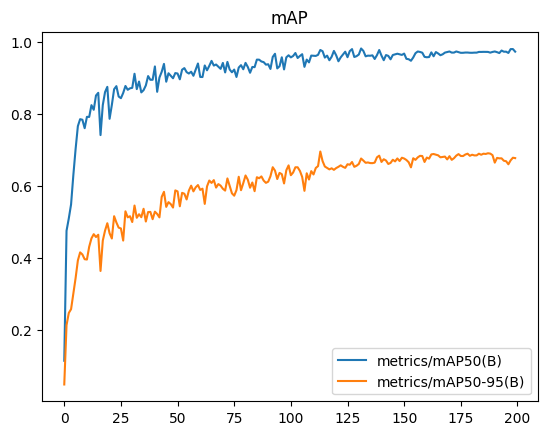

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = "/content/drive/MyDrive/NoonGil/runs/noongil_v5-4/results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

print(df[['epoch', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']].tail(10))

# 학습 곡선 시각화
df[['metrics/mAP50(B)', 'metrics/mAP50-95(B)']].plot(title="mAP")
plt.show()

### 클래스별 성능 분석 (취약 클래스 재확인)

In [23]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/NoonGil/runs/noongil_v5-4/weights/best.pt")

# validation 기준 per-class AP 출력
metrics = model.val(data="/content/data.yaml", imgsz=640)
print(metrics.box.maps)  # 클래스별 mAP50-95

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,378 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1676.8±395.9 MB/s, size: 45.9 KB)
val: Scanning /content/NoonGil-BarrierFree-AI-2/valid/labels.cache... 104 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 104/104 36.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 3.3it/s 2.2s
                   all        104        175      0.894      0.959      0.977      0.698
                 bench          3          5      0.506        0.6      0.817      0.632
               bicycle         26         30      0.984          1      0.995      0.693
               bollard         11         16      0.974          1      0.995       0.54
          clothing_bin         10         10      0.948          1      0.995      0.759
                  cone         10 

### 테스트 이미지 추론

Saving IMG_5658.heic to IMG_5658.heic
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 77.6 MB/s eta 0:00:00

image 1/1 /content/test_local/IMG_5658.jpg: 384x640 1 street_light, 1 tree, 6.6ms
Speed: 2.7ms preprocess, 6.6ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


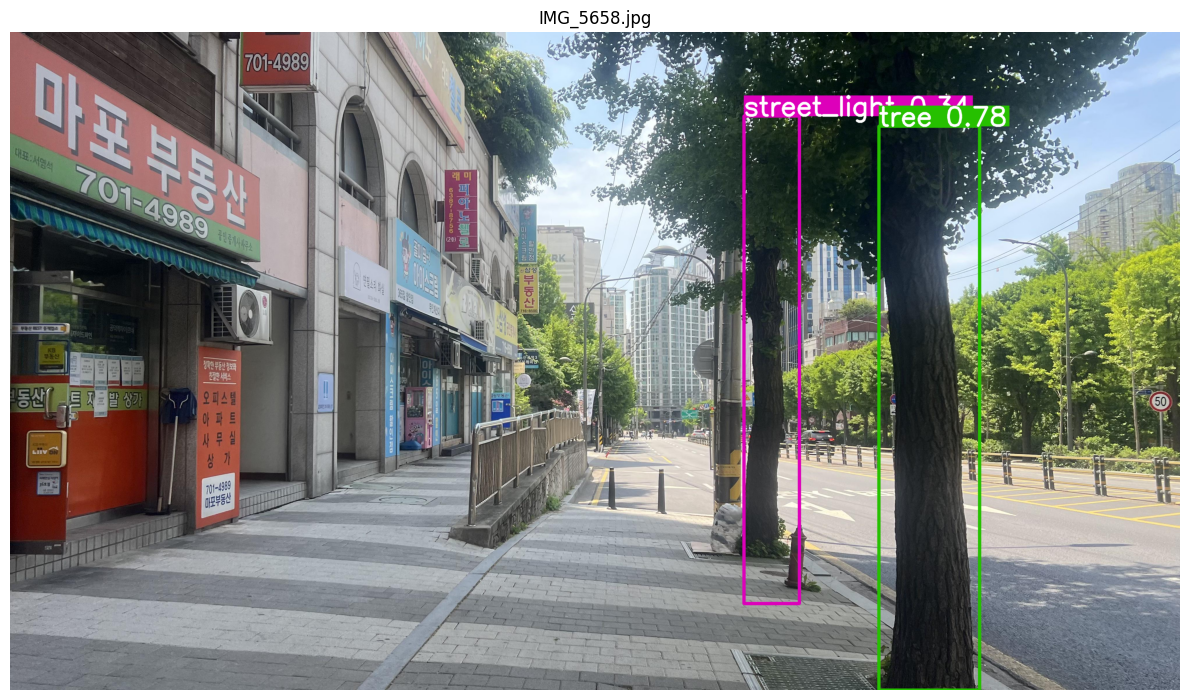

  → tree (0.78)
  → street_light (0.34)


In [26]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import io, os

uploaded = files.upload()

os.makedirs("/content/test_local", exist_ok=True)
for fname in uploaded.keys():
    os.rename(fname, f"/content/test_local/{fname}")

# HEIC → JPG 변환 (HEIC일 경우)
!pip install pillow-heif -q
from pillow_heif import register_heif_opener
register_heif_opener()

converted_paths = []
for fname in os.listdir("/content/test_local"):
    src = f"/content/test_local/{fname}"
    if fname.lower().endswith(".heic"):
        img = Image.open(src).convert("RGB")
        dst = src.replace(".heic", ".jpg").replace(".HEIC", ".jpg")
        img.save(dst)
        converted_paths.append(dst)
    else:
        converted_paths.append(src)

# 추론 + 인라인 시각화
for img_path in converted_paths:
    result = model.predict(img_path, conf=0.25)[0]

    # result.plot() → numpy array (BGR)
    import cv2
    annotated = result.plot()  # bounding box 그려진 이미지
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_rgb)
    plt.axis("off")
    plt.title(os.path.basename(img_path))
    plt.tight_layout()
    plt.show()

    # 감지된 클래스 출력
    for box in result.boxes:
        cls_id = int(box.cls)
        conf = float(box.conf)
        print(f"  → {result.names[cls_id]} ({conf:.2f})")

## 구글 드라이브 저장 및 확인

In [28]:
import os

drive_path = "/content/drive/MyDrive/NoonGil/runs"

for root, dirs, files in os.walk(drive_path):
    level = root.replace(drive_path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files:
        size = os.path.getsize(os.path.join(root, f)) / 1024 / 1024
        print(f"{indent}  {f} ({size:.1f}MB)")

runs/
  stage3_noongil_final/
    args.yaml (0.0MB)
    labels.jpg (0.1MB)
    train_batch0.jpg (0.7MB)
    train_batch1.jpg (0.7MB)
    train_batch2.jpg (0.6MB)
    val_batch1_pred.jpg (0.2MB)
    val_batch1_labels.jpg (0.2MB)
    BoxPR_curve.png (0.2MB)
    val_batch0_labels.jpg (0.6MB)
    val_batch0_pred.jpg (0.6MB)
    BoxF1_curve.png (0.3MB)
    BoxP_curve.png (0.2MB)
    BoxR_curve.png (0.2MB)
    confusion_matrix_normalized.png (0.2MB)
    confusion_matrix.png (0.2MB)
    results.png (0.3MB)
    results.csv (0.0MB)
    weights/
      last.pt (21.5MB)
      best.pt (21.5MB)
  noongil_v5/
    args.yaml (0.0MB)
    weights/
  noongil_v5-2/
    args.yaml (0.0MB)
    labels.jpg (0.2MB)
    train_batch0.jpg (0.6MB)
    train_batch1.jpg (0.6MB)
    train_batch2.jpg (0.6MB)
    results.csv (0.0MB)
    weights/
      best.pt (23.4MB)
      last.pt (23.4MB)
  noongil_v5-3/
    args.yaml (0.0MB)
    weights/
  noongil_v5-4/
    args.yaml (0.0MB)
    labels.jpg (0.2MB)
    train_batch0.jpg

In [29]:
checks = {
    "노트북": "/content/drive/MyDrive/NoonGil/runs",
    "best.pt": "/content/drive/MyDrive/NoonGil/runs/noongil_v5-4/weights/best.pt",
    "last.pt": "/content/drive/MyDrive/NoonGil/runs/noongil_v5-4/weights/last.pt",
    "results.csv": "/content/drive/MyDrive/NoonGil/runs/noongil_v5-4/results.csv",
    "추론 결과": "/content/drive/MyDrive/NoonGil/runs/noongil_v5_local_test",
}

for name, path in checks.items():
    exists = os.path.exists(path)
    print(f"{'✅' if exists else '❌'} {name}: {path}")

✅ 노트북: /content/drive/MyDrive/NoonGil/runs
✅ best.pt: /content/drive/MyDrive/NoonGil/runs/noongil_v5-4/weights/best.pt
✅ last.pt: /content/drive/MyDrive/NoonGil/runs/noongil_v5-4/weights/last.pt
✅ results.csv: /content/drive/MyDrive/NoonGil/runs/noongil_v5-4/results.csv
✅ 추론 결과: /content/drive/MyDrive/NoonGil/runs/noongil_v5_local_test


# 2차 하이퍼파라미터 튜닝

## STEP 1. Roboflow에서 데이터셋 다운로드

### YOLOv8 포맷으로 export

In [30]:
# Roboflow API로 다운로드 (pip install roboflow)
from roboflow import Roboflow

rf = Roboflow(api_key="vgvnQD3ktPGMXOXsiCG7")

# 1) pavement_damage용
proj1 = rf.workspace("projects-jszvc").project("road-crack-detection-htnrb")
proj1.version(1).download("yolov8")

# 2) bollard용
proj2 = rf.workspace("project-60htx").project("bollard-v2gn5")
proj2.version(1).download("yolov8")

# 3) electric_scooter용
proj3 = rf.workspace("escooter-nesne-em9gm").project("e-scooter-zfvnc")
proj3.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Road-Crack-Detection-1 in yolov8:: 100%|██████████| 3170/3170 [00:00<00:00, 5381.24it/s]

loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to bollard-1 in yolov8:: 100%|██████████| 2315/2315 [00:00<00:00, 5020.34it/s]

loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to E--Scooter-1 in yolov8:: 100%|██████████| 401/401 [00:00<00:00, 7644.97it/s]


## STEP 2. 디렉토리 구조 통일

In [61]:
import os
import shutil
from pathlib import Path

DATASETS = {
    # "crack":   Path("Road-Crack-Detection-1"),
    "bollard": Path("bollard-1"),
    "scooter": Path("E--Scooter-1"),
}

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

BASE = Path("NoonGil_dataset")
for split in ["train", "val"]:
    (BASE / "images" / split).mkdir(parents=True, exist_ok=True)
    (BASE / "labels" / split).mkdir(parents=True, exist_ok=True)

# Roboflow split명 → 출력 split명 매핑
# crack은 test도 있지만 학습/검증에만 사용
SPLIT_MAP = {
    "train": "train",
    "valid": "val",   # Roboflow는 valid, 우리는 val
    # "test" 는 제외
}

for prefix, ds_path in DATASETS.items():
    for src_split, dst_split in SPLIT_MAP.items():
        img_src = ds_path / src_split / "images"
        lbl_src = ds_path / src_split / "labels"

        if not img_src.exists():
            print(f"[SKIP] {ds_path}/{src_split}/images 없음")
            continue

        copied = 0
        for img_file in img_src.iterdir():
            if img_file.suffix.lower() not in IMG_EXTS:
                continue
            lbl_file = lbl_src / img_file.with_suffix(".txt").name
            if not lbl_file.exists():
                print(f"[WARN] 라벨 없음: {img_file.name}")
                continue

            new_stem = f"{prefix}_{img_file.stem}"
            shutil.copy(img_file, BASE / "images" / dst_split / f"{new_stem}{img_file.suffix}")
            shutil.copy(lbl_file, BASE / "labels" / dst_split / f"{new_stem}.txt")
            copied += 1

        print(f"[OK] {prefix}/{src_split} → {dst_split}: {copied}개 복사")

print("\n✅ 디렉토리 통일 완료")
for split in ["train", "val"]:
    n_img = len(list((BASE / "images" / split).iterdir()))
    n_lbl = len(list((BASE / "labels" / split).iterdir()))
    print(f"[{split}] images: {n_img}, labels: {n_lbl}")
    assert n_img == n_lbl, "⚠️ 이미지-라벨 수 불일치!"

[OK] bollard/train → train: 1076개 복사
[OK] bollard/valid → val: 77개 복사
[OK] scooter/train → train: 176개 복사
[OK] scooter/valid → val: 20개 복사

✅ 디렉토리 통일 완료
[train] images: 1989, labels: 1989
[val] images: 201, labels: 201


Roboflow export가 train/val 없이 flat하게 내려오는 경우 (split이 안 된 경우) 아래 코드로 직접 분할

In [62]:
# flat 구조일 때: images/, labels/ 바로 아래 파일이 있는 경우
for prefix, ds_path in DATASETS.items():
    img_src = ds_path / "images"
    lbl_src = ds_path / "labels"

    all_imgs = [f for f in img_src.iterdir()
                if f.suffix.lower() in IMG_EXTS
                and (lbl_src / f.with_suffix(".txt").name).exists()]

    train_imgs, val_imgs = train_test_split(all_imgs, test_size=0.2, random_state=42)

    for split, files in [("train", train_imgs), ("val", val_imgs)]:
        for img_file in files:
            lbl_file = lbl_src / img_file.with_suffix(".txt").name
            new_stem = f"{prefix}_{img_file.stem}"
            shutil.copy(img_file, BASE / "images" / split / f"{new_stem}{img_file.suffix}")
            shutil.copy(lbl_file, BASE / "labels" / split / f"{new_stem}.txt")

FileNotFoundError: [Errno 2] No such file or directory: 'bollard-1/images'

## STEP 3. 클래스 ID 리매핑

In [63]:
import os
from pathlib import Path

# NoonGil 기준 클래스 ID (현재 yaml 기준으로 수정 필요)
NOONGIL_CLASSES = {
    "bench":            0,
    "bicycle":          1,
    "bollard":          2,
    "clothing_bin":     3,
    "cone":             4,
    "electric_scooter": 5,
    "fire_hydrant":     6,
    "motorcycle":       7,
    "pavement_damage":  8,
    "ramp":             9,
    "step":             10,
    "street_light":     11,
    "trash":            12,
    "tree":             13,
}

def remap_labels(label_dir, source_classes, target_class_name, output_dir):
    """
    source_classes: 원본 데이터셋의 클래스 ID 목록 (모두 target으로 병합)
    target_class_name: NoonGil 클래스명
    """
    target_id = NOONGIL_CLASSES[target_class_name]
    os.makedirs(output_dir, exist_ok=True)

    for label_file in Path(label_dir).glob("*.txt"):
        new_lines = []
        with open(label_file, "r") as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                class_id = int(parts[0])

                if class_id in source_classes:
                    # 클래스 ID만 교체, bbox 좌표는 유지
                    new_lines.append(f"{target_id} {' '.join(parts[1:])}\n")
                # source_classes에 없는 클래스는 drop (e-scooter 데이터의 car 등)

        if new_lines:  # 유효한 라벨이 있을 때만 저장
            with open(Path(output_dir) / label_file.name, "w") as f:
                f.writelines(new_lines)

# 실행
remap_labels("road_crack/labels/train",
             source_classes={0,1,2,3,4,5,6},
             target_class_name="pavement_damage",
             output_dir="NoonGil_dataset/labels/train")

# bollard → bollard (ID: 2)
remap_labels("bollard/labels/train",
             source_classes={0,1,2,3,4},
             target_class_name="bollard",
             output_dir="NoonGil_dataset/labels/train")

# E-Scooter → electric_scooter (ID: 5)
remap_labels("escooter/labels/train",
             source_classes={0},
             target_class_name="electric_scooter",
             output_dir="NoonGil_dataset/labels/train")

## STEP 4. 파일명 충돌 방지

In [64]:
import shutil

def copy_with_prefix(src_img_dir, src_lbl_dir, dst_img_dir, dst_lbl_dir, prefix):
    os.makedirs(dst_img_dir, exist_ok=True)
    for img in Path(src_img_dir).glob("*.*"):
        shutil.copy(img, Path(dst_img_dir) / f"{prefix}_{img.name}")
    for lbl in Path(src_lbl_dir).glob("*.txt"):
        shutil.copy(lbl, Path(dst_lbl_dir) / f"{prefix}_{lbl.name}")

copy_with_prefix("road_crack/images/train", "road_crack/labels/train",
                 "NoonGil_dataset/images/train", "NoonGil_dataset/labels/train",
                 prefix="crack")

copy_with_prefix("bollard/images/train", "bollard/labels/train",
                 "NoonGil_dataset/images/train", "NoonGil_dataset/labels/train",
                 prefix="bollard")

copy_with_prefix("escooter/images/train", "escooter/labels/train",
                 "NoonGil_dataset/images/train", "NoonGil_dataset/labels/train",
                 prefix="scooter")

## STEP 5. 추가 데이터셋 샘플링 + 원본 데이터셋 병합

추가 데이터셋을 원본과 1:1 비율로 맞추는 샘플링 코드

In [66]:
import shutil, random
from pathlib import Path

random.seed(42)

BASE = Path("NoonGil_dataset")
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

# ── 1. 폴더 초기화 ──────────────────────────────────
if BASE.exists():
    shutil.rmtree(BASE)
for split in ["train", "val"]:
    (BASE / "images" / split).mkdir(parents=True, exist_ok=True)
    (BASE / "labels" / split).mkdir(parents=True, exist_ok=True)
print("✅ 초기화 완료")

# ── 2. 원본 데이터셋 복사 ────────────────────────────
ORIGINAL = Path("/content/drive/MyDrive/NoonGil/dataset")
for src_split, dst_split in [("train", "train"), ("valid", "val")]:
    img_src = ORIGINAL / src_split / "images"
    lbl_src = ORIGINAL / src_split / "labels"
    copied = 0
    for img_file in img_src.iterdir():
        if img_file.suffix.lower() not in IMG_EXTS:
            continue
        lbl_file = lbl_src / img_file.with_suffix(".txt").name
        if not lbl_file.exists():
            continue
        new_stem = f"original_{img_file.stem}"
        shutil.copy(img_file, BASE / "images" / dst_split / f"{new_stem}{img_file.suffix}")
        shutil.copy(lbl_file, BASE / "labels" / dst_split / f"{new_stem}.txt")
        copied += 1
    print(f"[원본/{src_split}] {copied}장 복사")

# ── 3. 추가 데이터셋 샘플링 후 복사 ─────────────────
DATASETS = {
    # "crack":   Path("Road-Crack-Detection-1"),
    "bollard": Path("bollard-1"),
    "scooter": Path("E--Scooter-1"),
}

SAMPLE_LIMIT = {
    # "crack": 250,  ← 제외
    "bollard": 400,
    "scooter": 337,
}

for prefix, ds_path in DATASETS.items():
    for src_split, dst_split in [("train", "train"), ("valid", "val")]:
        img_src = ds_path / src_split / "images"
        lbl_src = ds_path / src_split / "labels"
        if not img_src.exists():
            continue

        all_imgs = [
            f for f in img_src.iterdir()
            if f.suffix.lower() in IMG_EXTS
            and (lbl_src / f.with_suffix(".txt").name).exists()
        ]
        limit = SAMPLE_LIMIT[prefix] if dst_split == "train" else max(1, int(SAMPLE_LIMIT[prefix] * 0.2))
        sampled = random.sample(all_imgs, min(limit, len(all_imgs)))

        for img_file in sampled:
            lbl_file = lbl_src / img_file.with_suffix(".txt").name
            new_stem = f"{prefix}_{img_file.stem}"
            shutil.copy(img_file, BASE / "images" / dst_split / f"{new_stem}{img_file.suffix}")
            shutil.copy(lbl_file, BASE / "labels" / dst_split / f"{new_stem}.txt")

        print(f"[{prefix}/{src_split}] {len(all_imgs)}장 → {len(sampled)}장 샘플링")

# ── 4. 최종 확인 ────────────────────────────────────
print("\n=== 최종 규모 ===")
for split in ["train", "val"]:
    n_img = len(list((BASE / "images" / split).iterdir()))
    n_lbl = len(list((BASE / "labels" / split).iterdir()))
    print(f"[{split}] images: {n_img}, labels: {n_lbl}")
    assert n_img == n_lbl, "⚠️ 이미지-라벨 수 불일치!"

✅ 초기화 완료
[원본/train] 737장 복사
[원본/valid] 104장 복사
[bollard/train] 1076장 → 400장 샘플링
[bollard/valid] 77장 → 77장 샘플링
[scooter/train] 176장 → 176장 샘플링
[scooter/valid] 20장 → 20장 샘플링

=== 최종 규모 ===
[train] images: 1313, labels: 1313
[val] images: 201, labels: 201


## STEP 6. data.yaml 수정 후 재학습

In [67]:
import yaml

dataset_path = "/content/NoonGil_dataset"

data = {
    'path': dataset_path,
    'train': 'images/train',
    'val': 'images/val',
    'nc': 14,
    'names': [
        'bench', 'bicycle', 'bollard', 'clothing_bin', 'cone',
        'electric_scooter', 'fire_hydrant', 'motorcycle',
        'pavement_damage', 'ramp', 'step',
        'street_light', 'trash', 'tree'
    ]
}

yaml_path = "/content/data.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(data, f, allow_unicode=True)

print("✅ data.yaml 생성 완료")
print(open(yaml_path).read())

✅ data.yaml 생성 완료
names:
- bench
- bicycle
- bollard
- clothing_bin
- cone
- electric_scooter
- fire_hydrant
- motorcycle
- pavement_damage
- ramp
- step
- street_light
- trash
- tree
nc: 14
path: /content/NoonGil_dataset
train: images/train
val: images/val



In [68]:
from ultralytics import YOLO
import os

# Google Drive에 저장된 v5 체크포인트 경로 확인
drive_path = "/content/drive/MyDrive/NoonGil"

# Drive 내 best.pt 탐색
for root, dirs, files in os.walk(drive_path):
    for f in files:
        if f == "best.pt":
            print(os.path.join(root, f))

/content/drive/MyDrive/NoonGil/runs/stage3_noongil_final/weights/best.pt
/content/drive/MyDrive/NoonGil/runs/noongil_v5-2/weights/best.pt
/content/drive/MyDrive/NoonGil/runs/noongil_v5-4/weights/best.pt


In [69]:
from ultralytics import YOLO

# STEP 6 재학습 코드의 모델 경로 수정
model = YOLO("/content/drive/MyDrive/NoonGil/runs/noongil_v5-4/weights/best.pt")  # v5 체크포인트에서 Fine-tuning
model.train(
    data="data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    freeze=10,        # 초반 레이어 동결 → 기존 성능 보존
    name="v6_augmented"
)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/NoonGil/runs/noongil_v5-4/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v6_augmented-3, nbs=64, nms=False, opset=None, optimize=False, optimiz

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c9dcf5c4a40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.0

## STEP 7. 성능 평가

In [70]:
# 클래스별 mAP 확인
from ultralytics import YOLO
model = YOLO("/content/runs/detect/v6_augmented-2/weights/best.pt")
results = model.val(data="/content/data.yaml")

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,378 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1669.9±530.7 MB/s, size: 58.3 KB)
val: Scanning /content/NoonGil_dataset/labels/val.cache... 201 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 201/201 93.7Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 21, len(boxes) = 273. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.6it/s 3.6s
                   all        201        273      0.933      0.938      0.979      0.685
                 bench         23         26      0.738      0.808      0.845      0.645
               bicycle         26      

## STEP 8. 구글 드라이브 저장

In [71]:
import shutil
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive', force_remount=False)

DRIVE_BASE = Path("/content/drive/MyDrive/NoonGil")

# ── 1. 최종 모델 가중치 저장 ──────────────────────────
weights_src = Path("/content/runs/detect/v6_augmented-3/weights")
weights_dst = DRIVE_BASE / "runs" / "noongil_v6_augmented_3" / "weights"
weights_dst.mkdir(parents=True, exist_ok=True)

for f in weights_src.iterdir():
    shutil.copy(f, weights_dst / f.name)
    print(f"[weights] {f.name} 저장 완료")

# ── 2. 학습 결과 (그래프, 라벨 등) 저장 ─────────────
results_src = Path("/content/runs/detect/v6_augmented-3")
results_dst = DRIVE_BASE / "runs" / "noongil_v6_augmented_3"
results_dst.mkdir(parents=True, exist_ok=True)

for f in results_src.iterdir():
    if f.is_file():  # 파일만 (weights 폴더 제외)
        shutil.copy(f, results_dst / f.name)
        print(f"[results] {f.name} 저장 완료")

# ── 3. data.yaml 저장 ────────────────────────────────
shutil.copy("/content/data.yaml", DRIVE_BASE / "data_v6.yaml")
print("[yaml] data_v6.yaml 저장 완료")

# ── 4. 노트북 저장 확인 안내 ─────────────────────────
print("""
✅ Drive 저장 완료

저장 위치:
  가중치  : MyDrive/NoonGil/runs/noongil_v6_augmented_3/weights/
  결과물  : MyDrive/NoonGil/runs/noongil_v6_augmented_3/
  yaml    : MyDrive/NoonGil/data_v6.yaml

⚠️  노트북은 Colab 상단 '저장' 또는 Ctrl+S로 별도 저장 필요
""")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[weights] best.pt 저장 완료
[weights] last.pt 저장 완료
[results] val_batch1_pred.jpg 저장 완료
[results] BoxPR_curve.png 저장 완료
[results] train_batch2.jpg 저장 완료
[results] val_batch2_pred.jpg 저장 완료
[results] train_batch3320.jpg 저장 완료
[results] val_batch2_labels.jpg 저장 완료
[results] confusion_matrix.png 저장 완료
[results] train_batch0.jpg 저장 완료
[results] val_batch1_labels.jpg 저장 완료
[results] val_batch0_labels.jpg 저장 완료
[results] results.csv 저장 완료
[results] BoxP_curve.png 저장 완료
[results] BoxR_curve.png 저장 완료
[results] labels.jpg 저장 완료
[results] val_batch0_pred.jpg 저장 완료
[results] train_batch3322.jpg 저장 완료
[results] confusion_matrix_normalized.png 저장 완료
[results] BoxF1_curve.png 저장 완료
[results] train_batch1.jpg 저장 완료
[results] results.png 저장 완료
[results] args.yaml 저장 완료
[results] train_batch3321.jpg 저장 완료
[yaml] data_v6.yaml 저장 완료

✅ Drive 저장 완료

저장 위치:
  가중치  : MyDrive/NoonGil/